In [27]:
# ===============================
# 0. Set Graphviz PATH
# ===============================
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import graphviz

In [4]:
# ===============================
# 2. Load dataset
# ===============================
DATA_PATH = r"C:\Users\huyen\Source\Repos\decision_tree_csai\data\diabetes.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Dataset shape: (520, 17)

First few rows:
   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class 

In [5]:
# ===============================
# 3. Split features & labels
# ===============================
X = df.drop(columns=["class"])
y = df["class"]

# Encode label
y = y.map({"Positive": 1, "Negative": 0})

# One-hot encoding for features
X_encoded = pd.get_dummies(X, drop_first=True)

# Feature names after one-hot encoding
print("Feature names:", X_encoded.columns.tolist())

Feature names: ['Age', 'Gender_Male', 'Polyuria_Yes', 'Polydipsia_Yes', 'sudden weight loss_Yes', 'weakness_Yes', 'Polyphagia_Yes', 'Genital thrush_Yes', 'visual blurring_Yes', 'Itching_Yes', 'Irritability_Yes', 'delayed healing_Yes', 'partial paresis_Yes', 'muscle stiffness_Yes', 'Alopecia_Yes', 'Obesity_Yes']


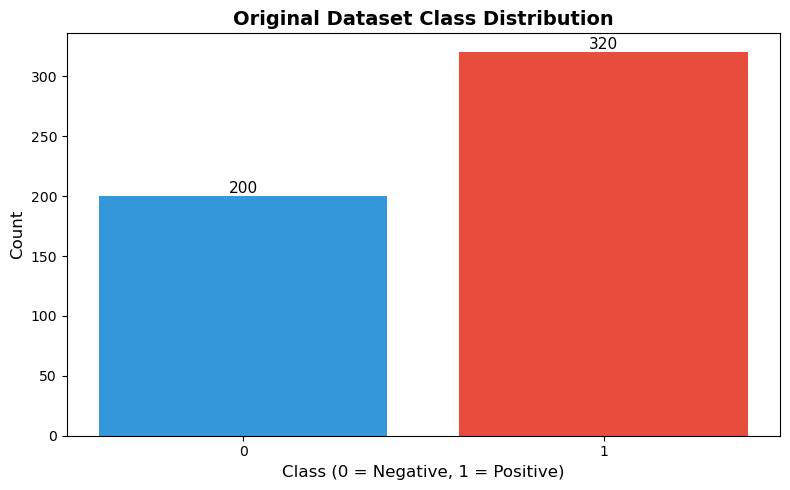

In [6]:
# ===============================
# 4. Plot class distribution
# ===============================
def plot_class_distribution(y, title):
    """Plot bar chart of class distribution"""
    counts = y.value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    bars = plt.bar(counts.index.astype(str), counts.values, color=['#3498db', '#e74c3c'])
    plt.xlabel("Class (0 = Negative, 1 = Positive)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()


# Original dataset
plot_class_distribution(y, "Original Dataset Class Distribution")

In [29]:
# ===============================
# 5. Prepare train/test splits
# ===============================
print("\n" + "="*60)
print("PREPARING TRAIN/TEST SPLITS")
print("="*60)

splits = [(0.4, 0.6), (0.6, 0.4), (0.8, 0.2), (0.9, 0.1)]
datasets = {}

for train_ratio, test_ratio in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y,
        train_size=train_ratio,
        test_size=test_ratio,
        shuffle=True,
        stratify=y,
    )

    key = f"{int(train_ratio*100)}_{int(test_ratio*100)}"

    datasets[key] = {
        "feature_train": X_train,
        "label_train": y_train,
        "feature_test": X_test,
        "label_test": y_test
    }
    
    print(f"\nSplit {key}:")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")


PREPARING TRAIN/TEST SPLITS

Split 40_60:
  Training samples: 208
  Test samples: 312

Split 60_40:
  Training samples: 312
  Test samples: 208

Split 80_20:
  Training samples: 416
  Test samples: 104

Split 90_10:
  Training samples: 468
  Test samples: 52



VISUALIZING CLASS DISTRIBUTIONS


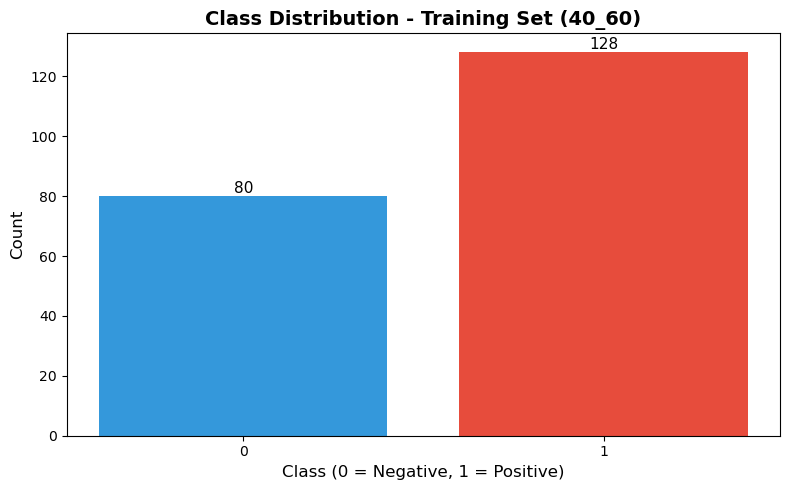

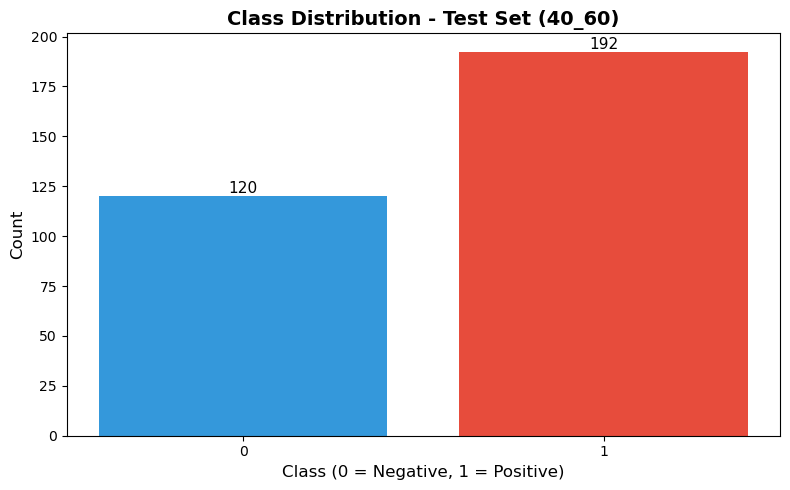

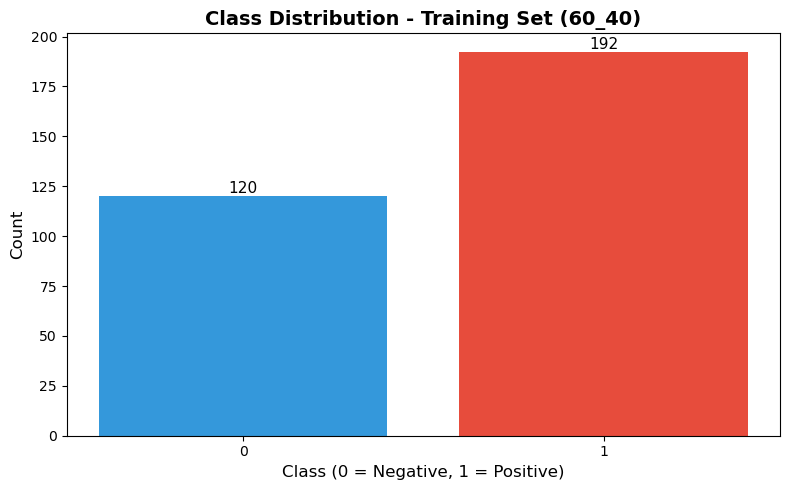

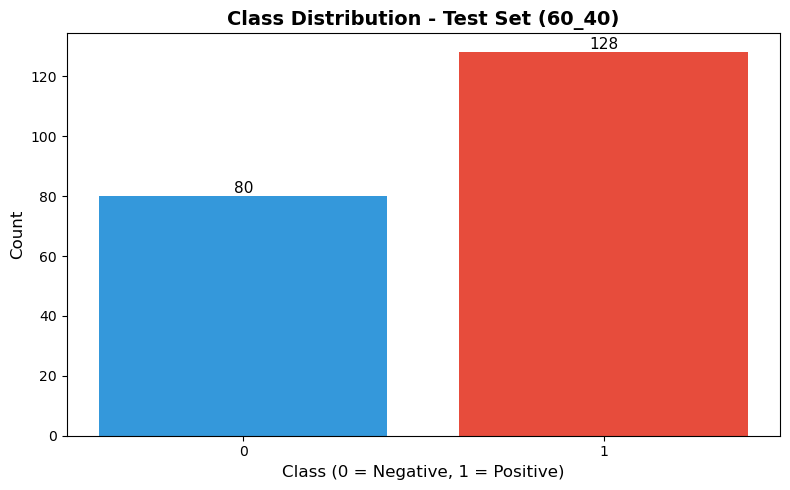

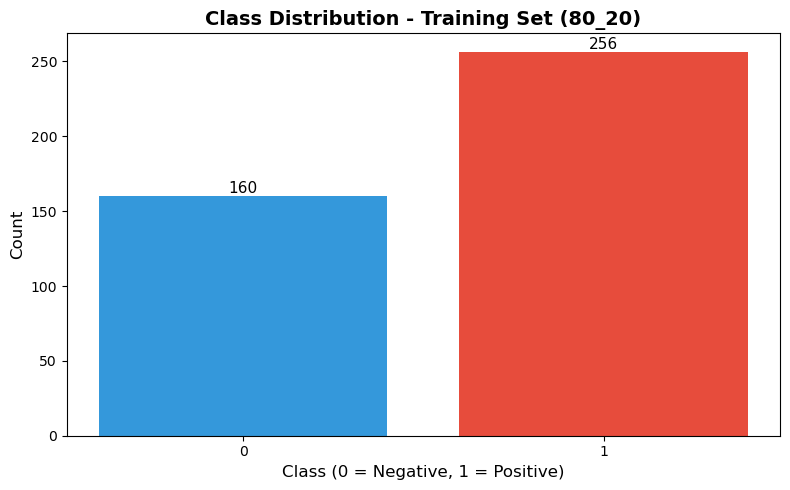

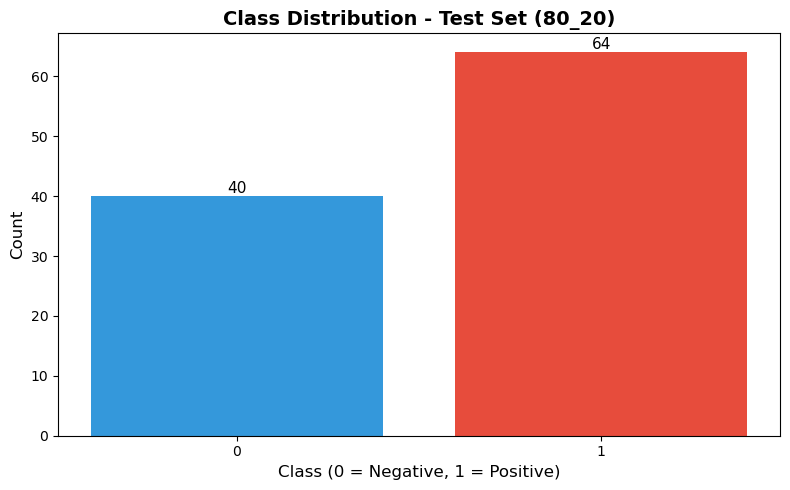

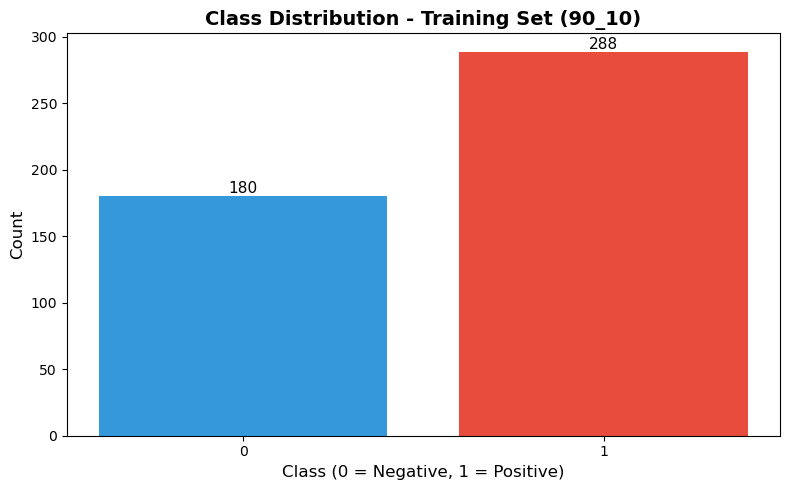

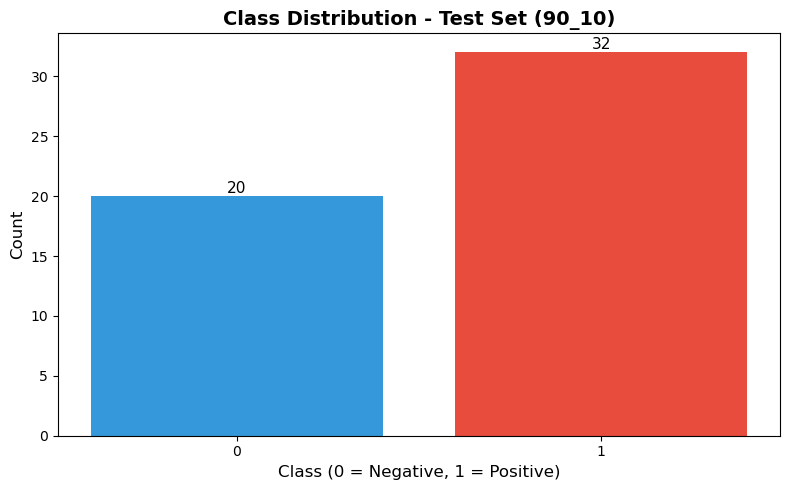

In [8]:
# ===============================
# 6. Visualize class distributions
# ===============================
print("\n" + "="*60)
print("VISUALIZING CLASS DISTRIBUTIONS")
print("="*60)

for name, data in datasets.items():
    plot_class_distribution(
        data["label_train"],
        f"Class Distribution - Training Set ({name})"
    )

    plot_class_distribution(
        data["label_test"],
        f"Class Distribution - Test Set ({name})"
    )


TRAINING DECISION TREES

Training model for split 40_60...
  Tree depth: 3
  Number of leaves: 21

Training model for split 60_40...
  Tree depth: 3
  Number of leaves: 25

Training model for split 80_20...
  Tree depth: 3
  Number of leaves: 32

Training model for split 90_10...
  Tree depth: 3
  Number of leaves: 32

VISUALIZING DECISION TREES

Visualizing tree for split 40_60...


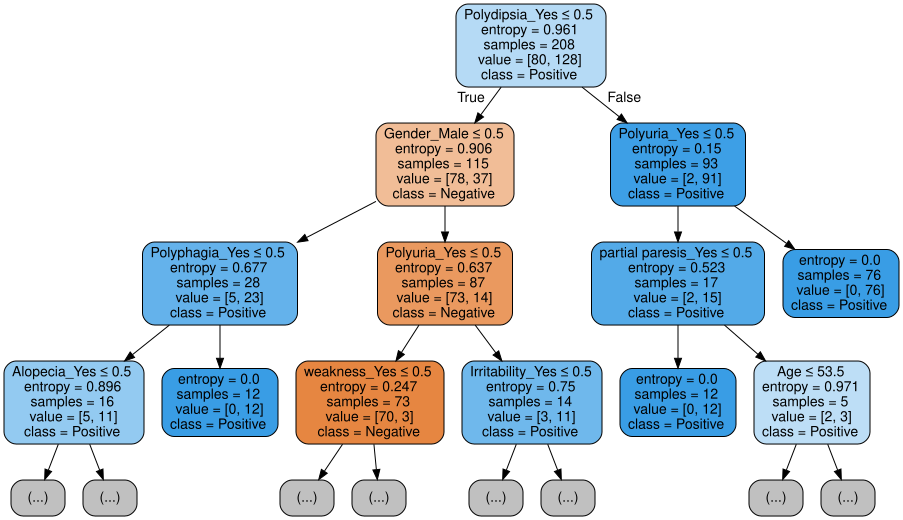


Visualizing tree for split 60_40...


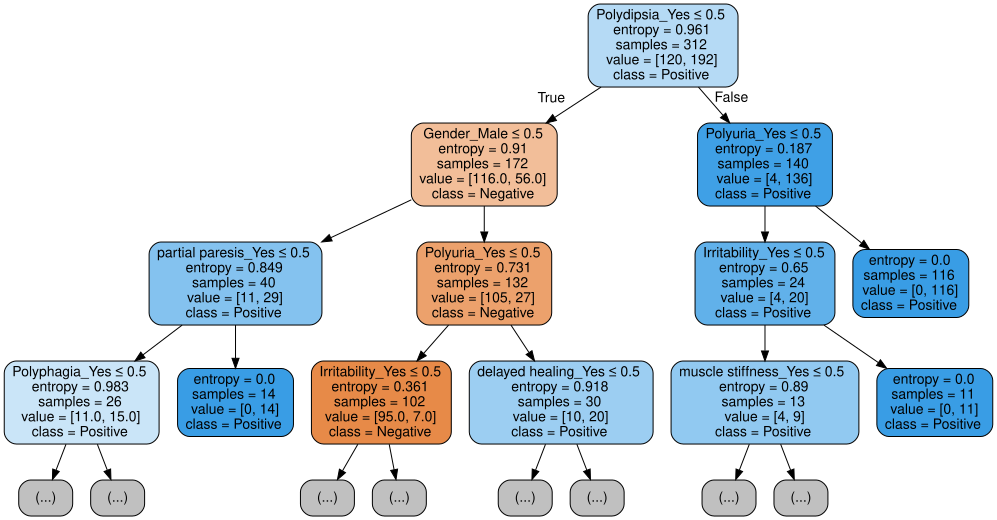


Visualizing tree for split 80_20...


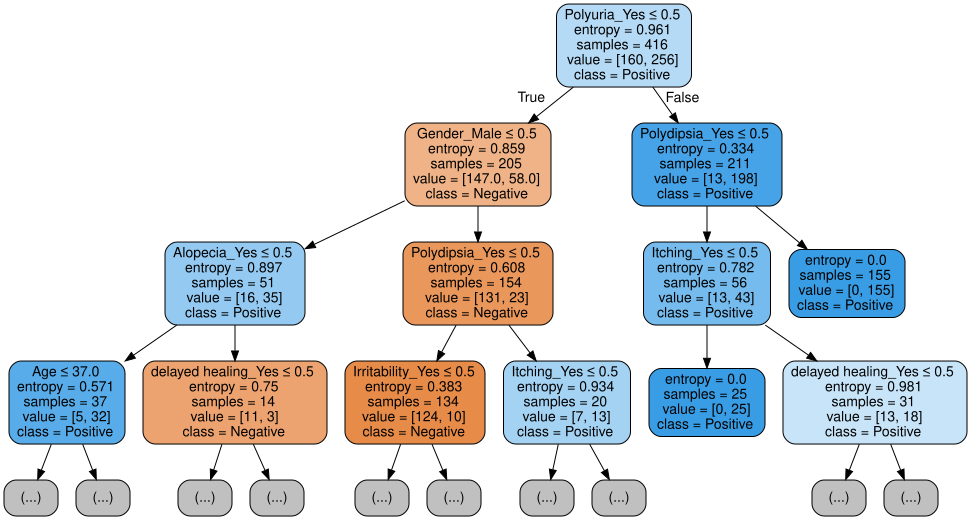


Visualizing tree for split 90_10...


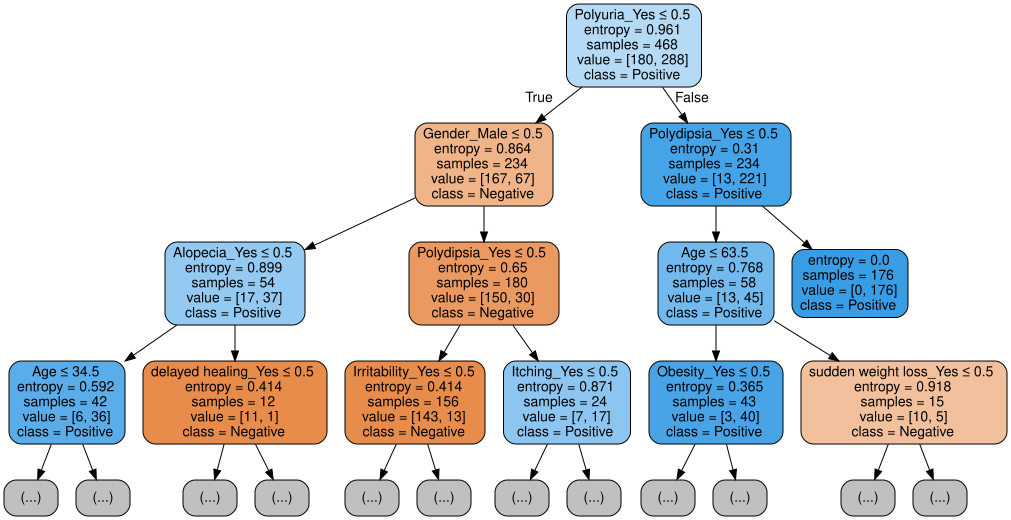

In [35]:
# ===============================
# 7. Train Decision Trees
# ===============================
print("\n" + "="*60)
print("TRAINING DECISION TREES")
print("="*60)

models = {}
tree_max_depth = 3 

for name, data in datasets.items():
    print(f"\nTraining model for split {name}...")
    model = DecisionTreeClassifier(criterion="entropy")
    model.fit(data["feature_train"], data["label_train"])
    models[name] = model
    print(f"  Tree depth: {tree_max_depth}")
    print(f"  Number of leaves: {model.get_n_leaves()}")


# ===============================
# 7.1. Visualize all trained trees
# ===============================
print("\n" + "="*60)
print("VISUALIZING DECISION TREES")
print("="*60)

for name, model in models.items():
    print(f"\nVisualizing tree for split {name}...")
    
    # Export to graphviz format
    dot_data = export_graphviz(
        model,
        out_file=None,
        feature_names=X_encoded.columns,
        class_names=["Negative", "Positive"],
        filled=True,
        rounded=True,
        special_characters=True,
        max_depth = 3
    )
    
    # Create graph
    graph = graphviz.Source(dot_data)
    
    # Display in notebook
    display(graph)


MODEL EVALUATION

EVALUATION FOR SPLIT 40_60

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.93      0.91       120
    Positive       0.95      0.93      0.94       192

    accuracy                           0.93       312
   macro avg       0.92      0.93      0.92       312
weighted avg       0.93      0.93      0.93       312


Confusion Matrix:
[[111   9]
 [ 14 178]]


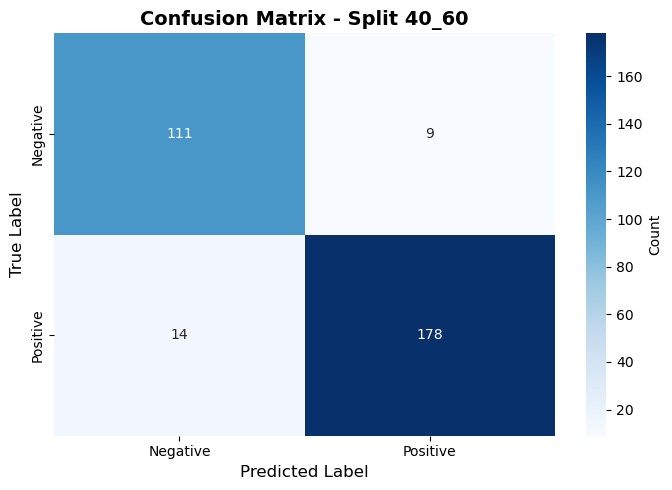


EVALUATION FOR SPLIT 60_40

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.95      0.93        80
    Positive       0.97      0.94      0.95       128

    accuracy                           0.94       208
   macro avg       0.94      0.94      0.94       208
weighted avg       0.94      0.94      0.94       208


Confusion Matrix:
[[ 76   4]
 [  8 120]]


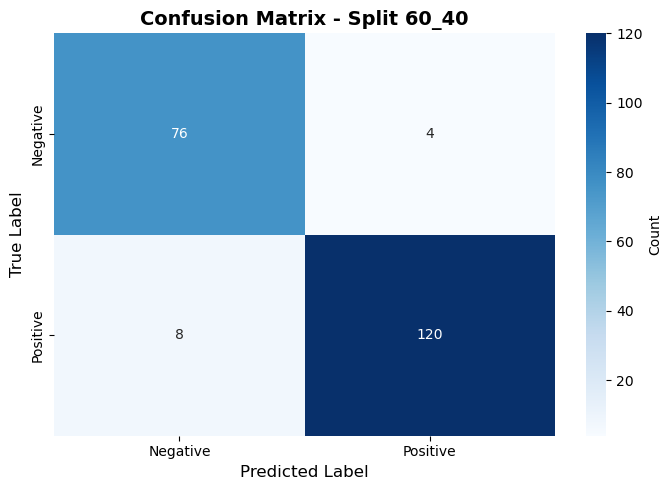


EVALUATION FOR SPLIT 80_20

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        40
    Positive       1.00      0.97      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104


Confusion Matrix:
[[40  0]
 [ 2 62]]


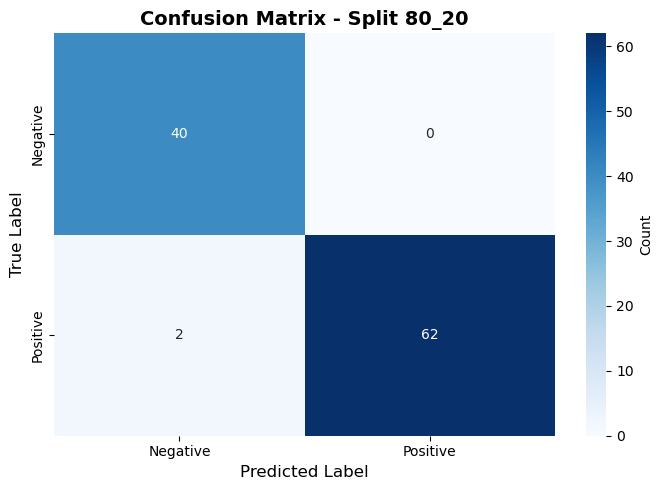


EVALUATION FOR SPLIT 90_10

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        32

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52


Confusion Matrix:
[[20  0]
 [ 0 32]]


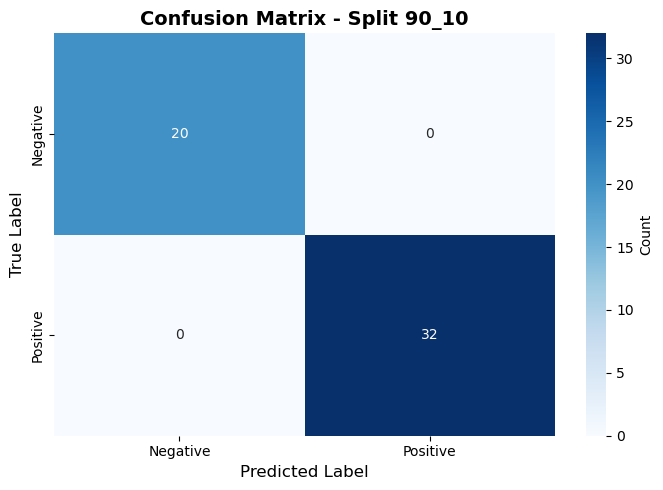

In [37]:
# ===============================
# 8. Evaluate models
# ===============================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

for name, data in datasets.items():
    print(f"\n{'='*60}")
    print(f"EVALUATION FOR SPLIT {name}")
    print(f"{'='*60}")

    y_pred = models[name].predict(data["feature_test"])

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(data["label_test"], y_pred, 
                                target_names=["Negative", "Positive"]))

    # Confusion Matrix (text)
    cm = confusion_matrix(data["label_test"], y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Confusion Matrix (heatmap)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"],
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix - Split {name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    


EXPLORING TREE DEPTH (80/20 SPLIT)

Training with max_depth=None...
  Accuracy: 0.9904
  Actual tree depth: 10
  Number of leaves: 33
  Visualizing tree with max_depth=None...


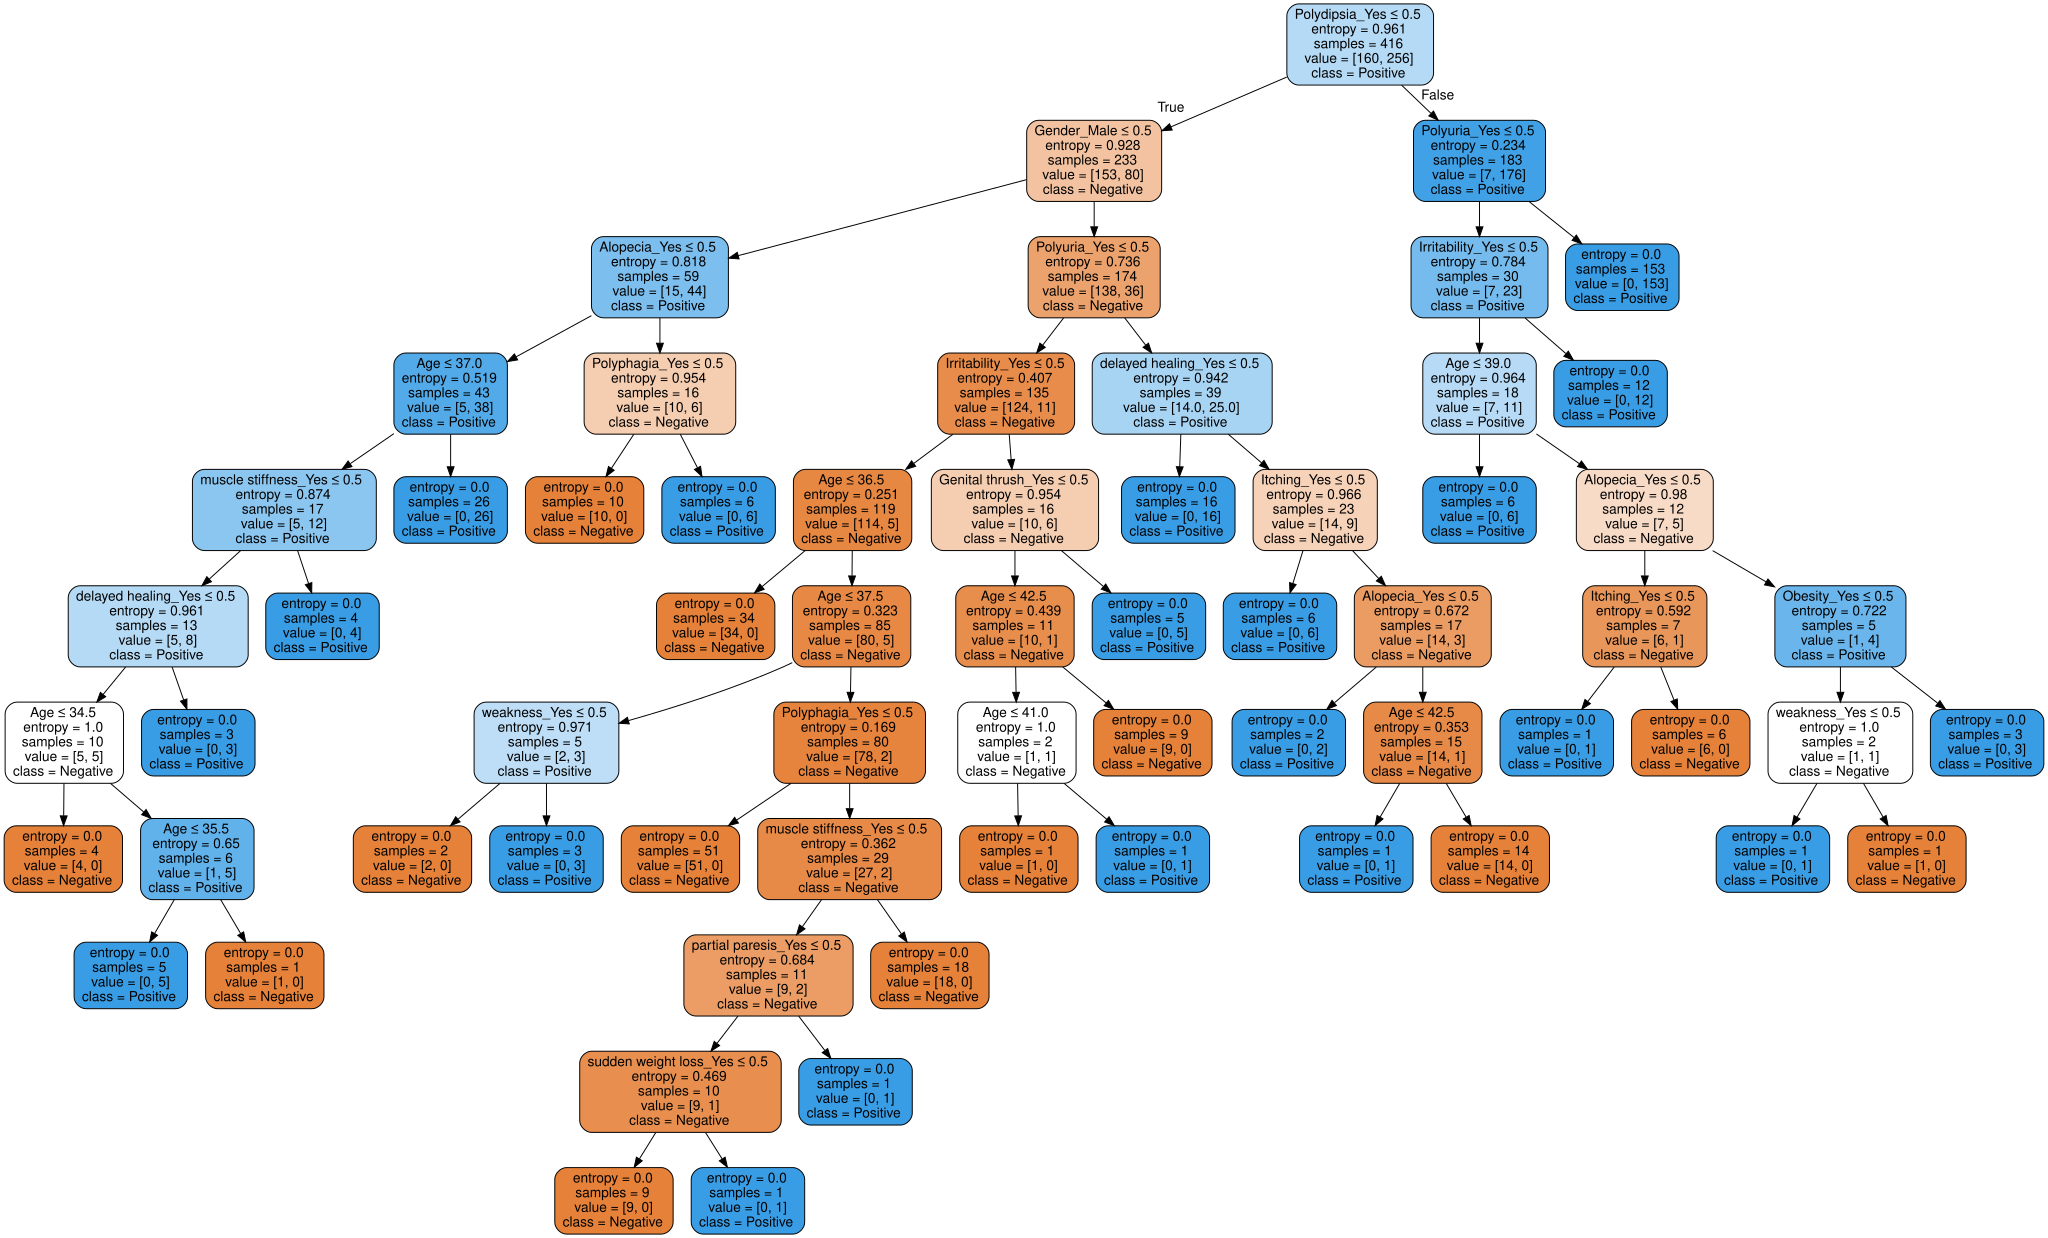


Training with max_depth=2...
  Accuracy: 0.8462
  Actual tree depth: 2
  Number of leaves: 4
  Visualizing tree with max_depth=2...


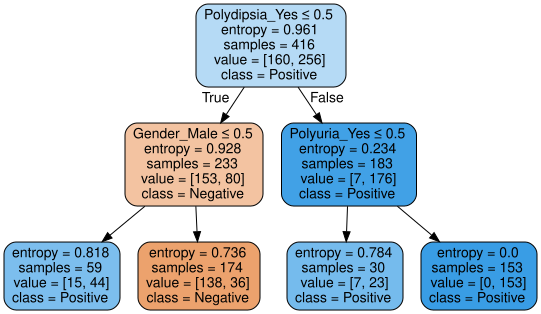


Training with max_depth=3...
  Accuracy: 0.9423
  Actual tree depth: 3
  Number of leaves: 7
  Visualizing tree with max_depth=3...


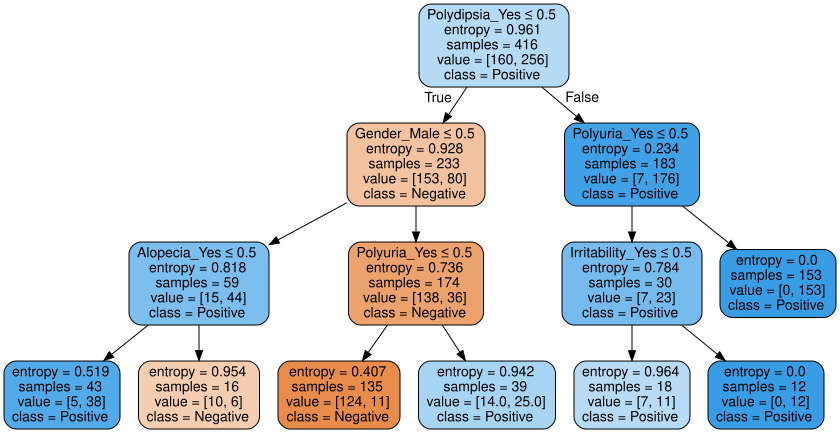


Training with max_depth=4...
  Accuracy: 0.9038
  Actual tree depth: 4
  Number of leaves: 12
  Visualizing tree with max_depth=4...


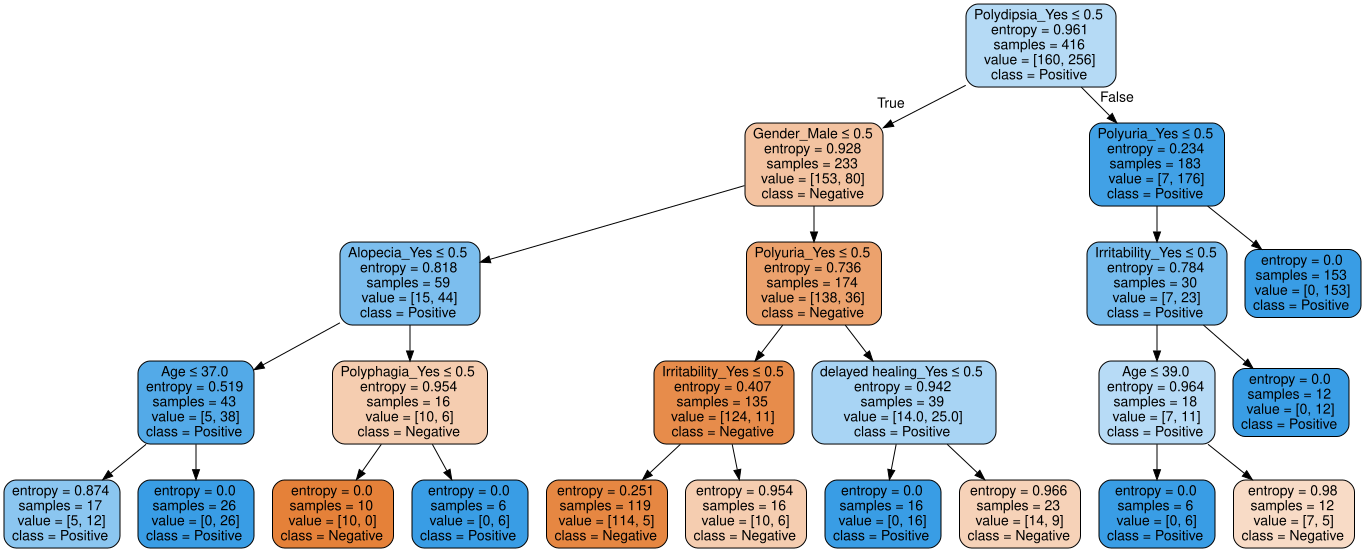


Training with max_depth=5...
  Accuracy: 0.9423
  Actual tree depth: 5
  Number of leaves: 17
  Visualizing tree with max_depth=5...


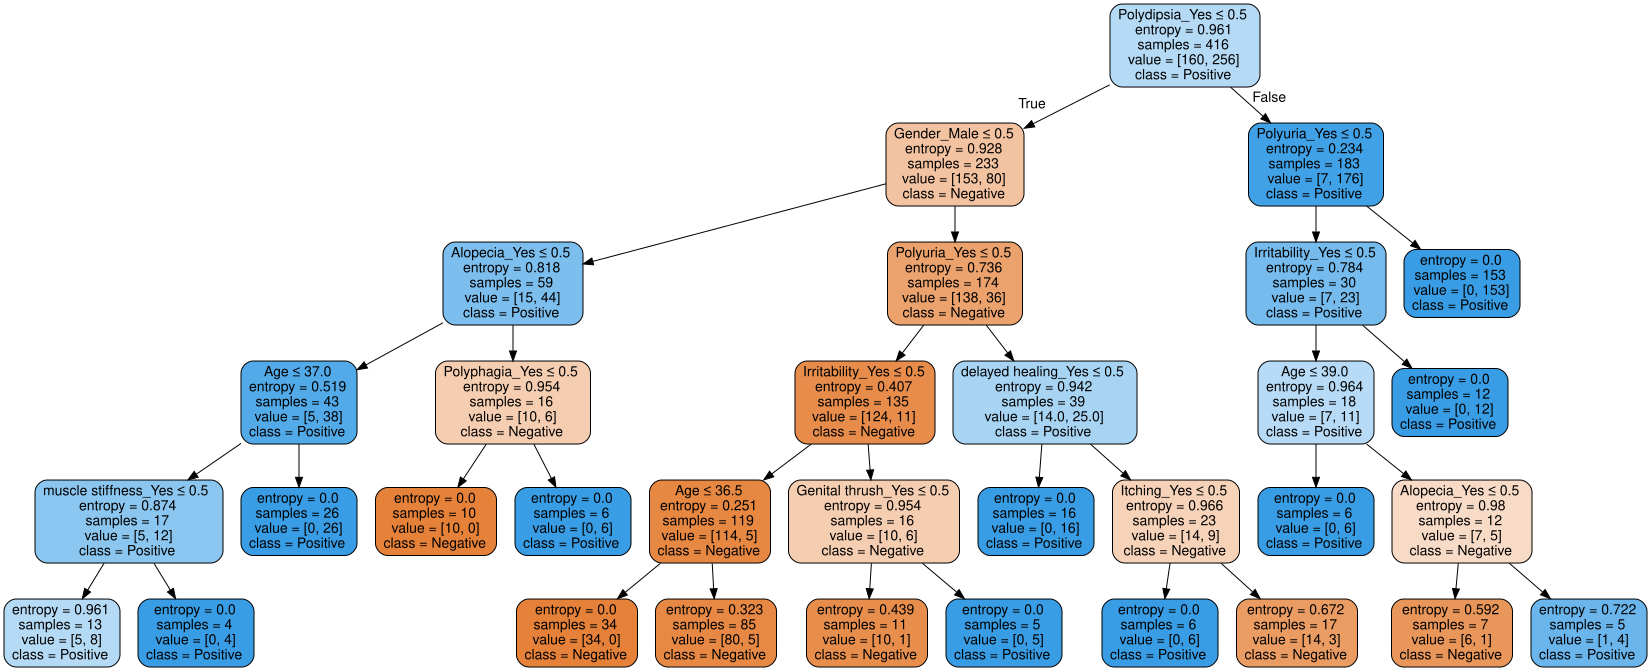


Training with max_depth=6...
  Accuracy: 0.9327
  Actual tree depth: 6
  Number of leaves: 23
  Visualizing tree with max_depth=6...


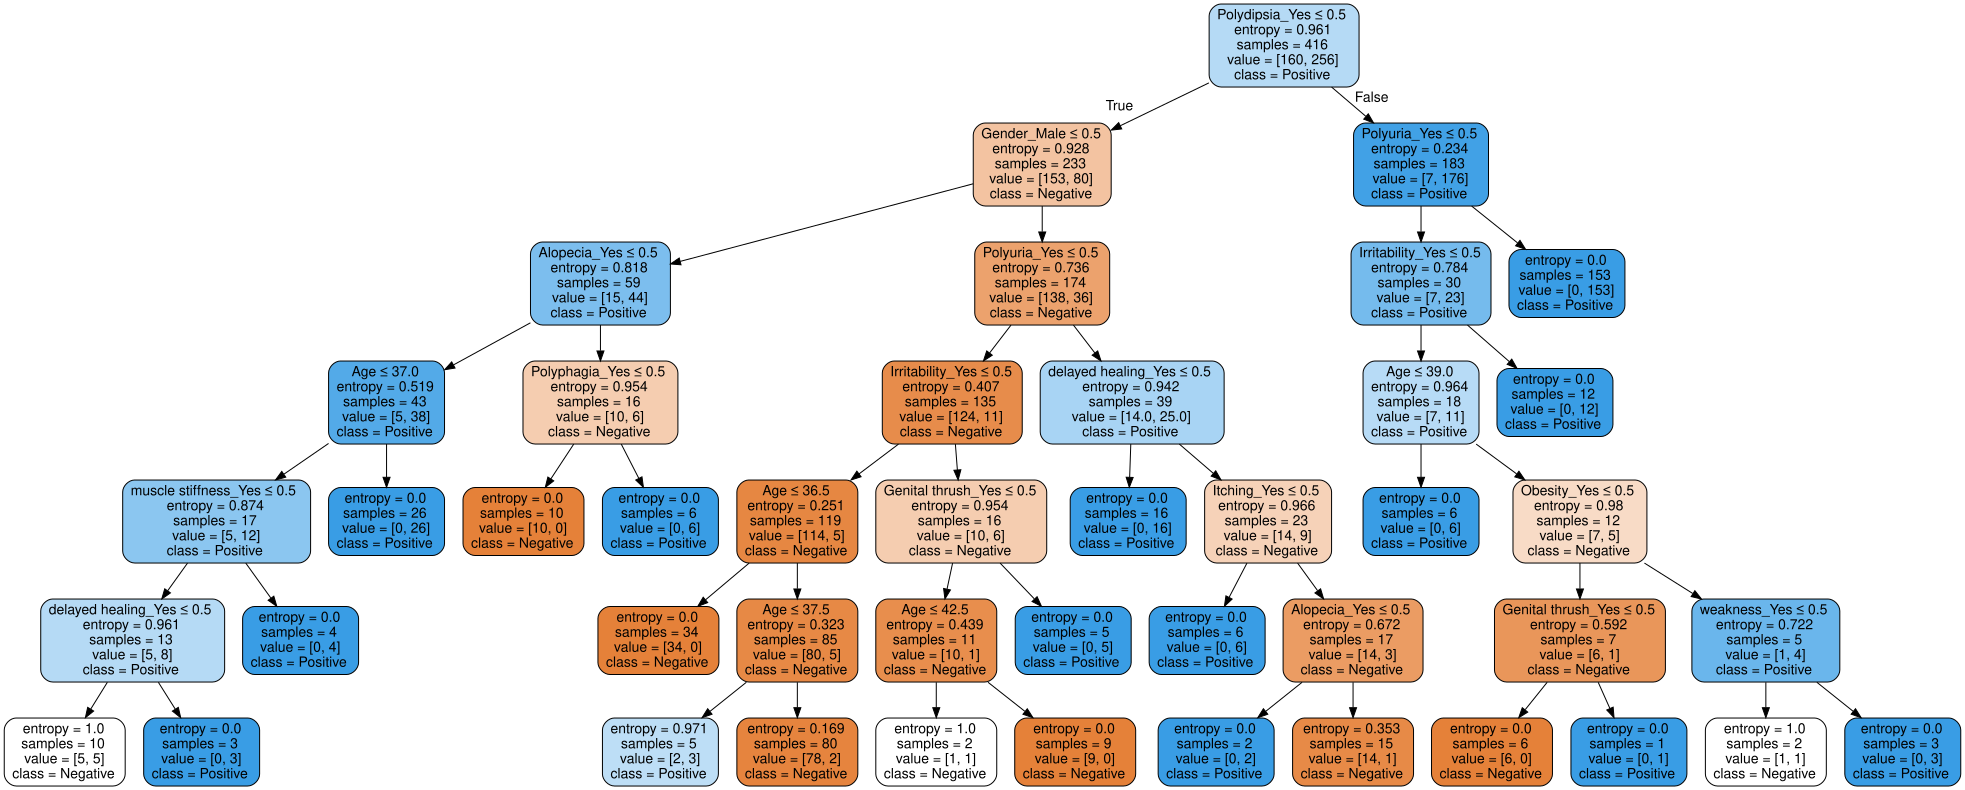


Training with max_depth=7...
  Accuracy: 0.9808
  Actual tree depth: 7
  Number of leaves: 29
  Visualizing tree with max_depth=7...


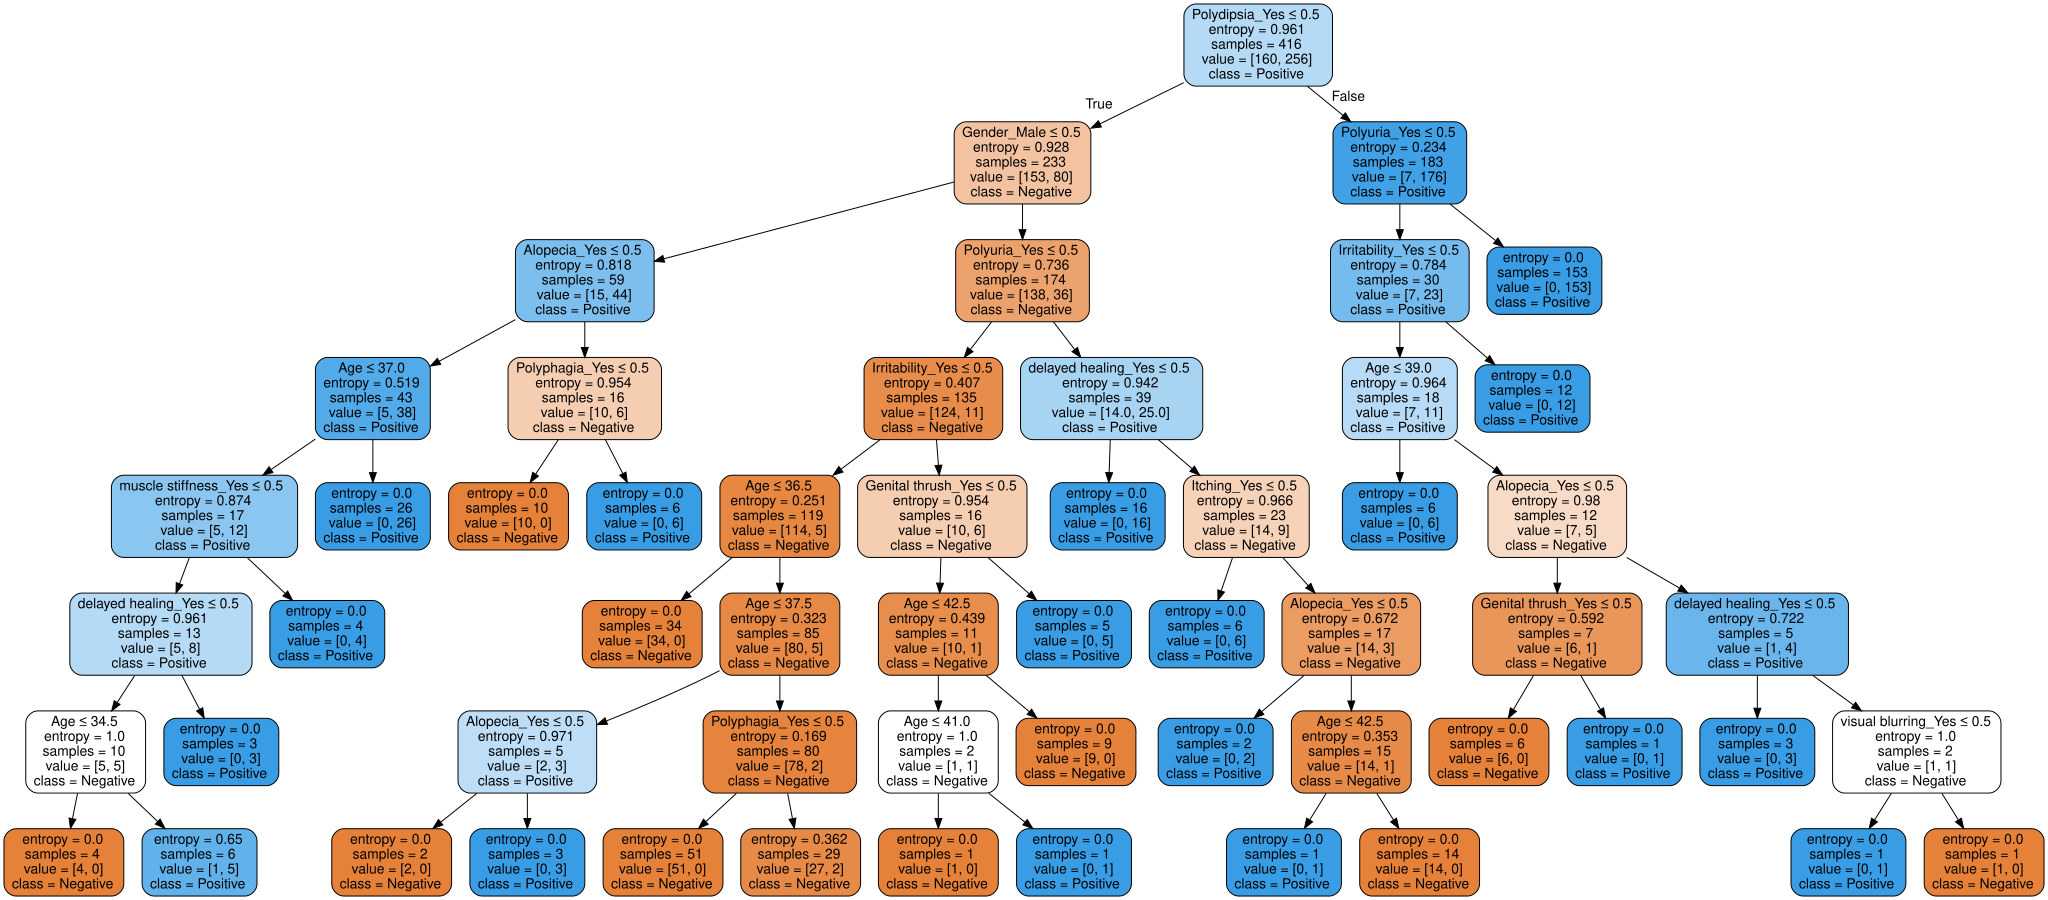

In [25]:
# ===============================
# 9. Train with different max_depth (80/20 split)
# ===============================
print("\n" + "="*60)
print("EXPLORING TREE DEPTH (80/20 SPLIT)")
print("="*60)

X_train = datasets["80_20"]["feature_train"]
X_test  = datasets["80_20"]["feature_test"]
y_train = datasets["80_20"]["label_train"]
y_test  = datasets["80_20"]["label_test"]

depths = [None, 2, 3, 4, 5, 6, 7]
accuracy_results = []

for depth in depths:
    print(f"\nTraining with max_depth={depth}...")
    
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results.append(acc)
    
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Actual tree depth: {model.get_depth()}")
    print(f"  Number of leaves: {model.get_n_leaves()}")

    # Visualize tree with Graphviz
    depth_str = str(depth) if depth is not None else "None"
    print(f"  Visualizing tree with max_depth={depth_str}...")
    
    dot_data = export_graphviz(
        model,
        out_file=None,
        feature_names=X_train.columns,
        class_names=["Negative", "Positive"],
        filled=True,
        rounded=True,
        special_characters=True
    )
    
    graph = graphviz.Source(dot_data)
    display(graph)
    


ACCURACY SUMMARY TABLE

max_depth       Accuracy       
--------------------------------------------------
None            0.9904         
2               0.8462         
3               0.9423         
4               0.9038         
5               0.9423         
6               0.9327         
7               0.9808         


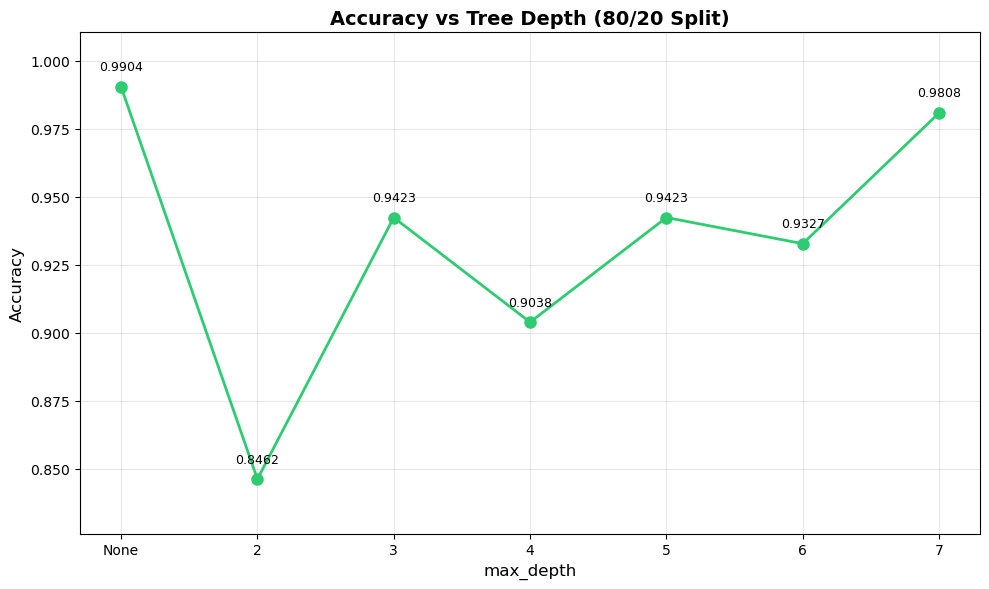

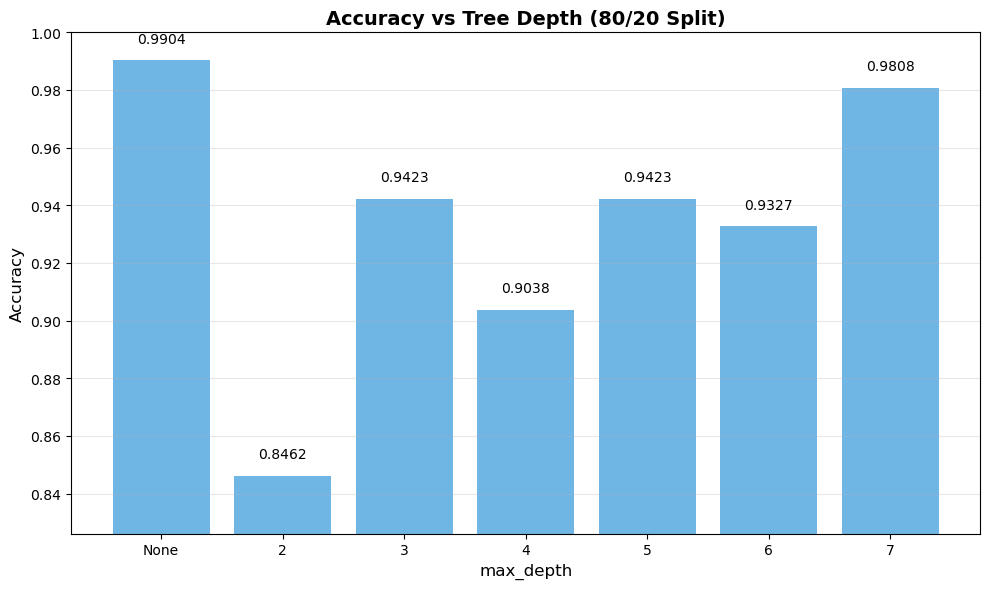

In [12]:
# ===============================
# 10. Accuracy table & plot
# ===============================
print("\n" + "="*60)
print("ACCURACY SUMMARY TABLE")
print("="*60)

accuracy_df = pd.DataFrame({
    "max_depth": depths,
    "accuracy": accuracy_results
})


# Formatted table
print("\n" + "="*50)
print(f"{'max_depth':<15} {'Accuracy':<15}")
print("-"*50)
for depth, acc in zip(depths, accuracy_results):
    depth_str = str(depth) if depth is not None else "None"
    print(f"{depth_str:<15} {acc:<15.4f}")
print("="*50)

# Plot accuracy vs depth
depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(10, 6))
plt.plot(depth_labels, accuracy_df["accuracy"], marker='o', linewidth=2, 
         markersize=8, color='#2ecc71')
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Tree Depth (80/20 Split)", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.ylim([min(accuracy_results) - 0.02, max(accuracy_results) + 0.02])

# Add value labels on points
for i, (label, acc) in enumerate(zip(depth_labels, accuracy_results)):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Bar chart alternative
plt.figure(figsize=(10, 6))
bars = plt.bar(depth_labels, accuracy_df["accuracy"], color='#3498db', alpha=0.7)
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Tree Depth (80/20 Split)", fontsize=14, fontweight='bold')
plt.ylim([min(accuracy_results) - 0.02, 1.0])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracy_results):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()